# NumPy 이미지 데이터 실습 교안

이 노트북은 이미지 데이터를 활용해 NumPy 핵심 기능을 연습하기 위한 교안입니다.

## 준비물
- `sample.jpg` 라는 이미지 파일 (아무 사진이나 가능)
- Python, NumPy, Pillow(PIL), matplotlib

## 목차
0. 준비 (이미지 → NumPy 배열)
1. 배열 구조 이해: shape / dtype / 픽셀 접근
2. 채널 다루기 (R,G,B 분리 & 합치기)
3. 브로드캐스팅으로 밝기/대비 조절
4. 자르기 / 붙이기 / 확대 (슬라이싱 & `np.concatenate` / `np.repeat`)
5. 마스킹 (Boolean indexing)
6. 간단한 블러 필터 직접 만들기
7. 여러 장의 이미지를 한 번에 다루기 (배치)
8. 미니 프로젝트: 돋보기 스티커 합성

---


## 0. 준비: 이미지 불러오기

목표:
- 이미지를 NumPy 배열로 변환
- "이미지는 (높이, 너비, 채널) 형태의 숫자 배열"임을 확인


배열 타입: <class 'numpy.ndarray'>
배열 shape: (505, 1000, 3)
배열 dtype: uint8


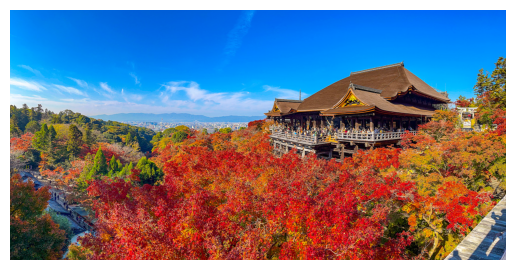

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1) 이미지 불러오기 (sample.jpg 라는 파일이 같은 폴더에 있다고 가정)
img = Image.open("./data/sample1.jpg")  # 컬러 이미지 불러오기
img_arr = np.array(img)          # PIL.Image -> NumPy 배열

print("배열 타입:", type(img_arr))
print("배열 shape:", img_arr.shape)   # (높이, 너비, 채널)
print("배열 dtype:", img_arr.dtype)   # 보통 uint8 (0~255)

# 2) 시각화

plt.imshow(img_arr)
plt.axis('off')
plt.show()

**연습문제 0**
1. 다른 이미지를 하나 더 불러와서 `img2_arr`를 만들고 `shape`과 `dtype`을 비교하세요.
2. `Image.open(...).convert("L")` 로 흑백 이미지를 불러오면 `shape`가 어떻게 달라지는지 확인하세요.


## 1. 배열 구조 이해: shape, dtype, 픽셀 접근

핵심 NumPy 개념:
- `shape`
- 인덱싱 (arr[y, x, c])
- 슬라이싱


높이: 505 너비: 1000 채널수: 3
(100,200) 위치 픽셀 RGB: [  0 132 241]
해당 픽셀의 R 값: 0


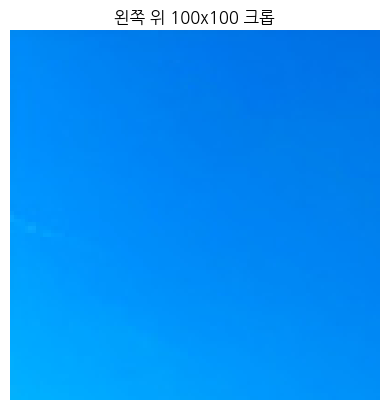

In [10]:
h, w, c = img_arr.shape
print("높이:", h, "너비:", w, "채널수:", c)

# (y=100, x=200) 픽셀의 RGB 값
pixel = img_arr[100, 200]
print("(100,200) 위치 픽셀 RGB:", pixel)

# 빨간 채널(R)만
red_value = img_arr[100, 200, 0]
print("해당 픽셀의 R 값:", red_value)

# 왼쪽 위 100x100 영역 (crop)
patch = img_arr[0:100, 0:100, :]
plt.imshow(patch)
plt.axis('off')
plt.title("왼쪽 위 100x100 크롭")
plt.show()

**연습문제 1**
1. 이미지의 정중앙 50x50 영역을 잘라서 시각화하세요. (힌트: `h//2`, `w//2`)
2. 오른쪽 아래 100x100 크롭을 `bottom_right` 변수에 저장하고 시각화하세요.
3. `img_arr / 255.0` 을 이용해 `0~1` 범위의 `float32` 배열(`img_float`)을 만들어보세요.


## 2. 채널 다루기 (R,G,B 분리 & 다시 합치기)

핵심 NumPy 개념:
- 다차원 슬라이싱 (`arr[:, :, 0]` 등)
- axis 재조합 (`np.dstack`)


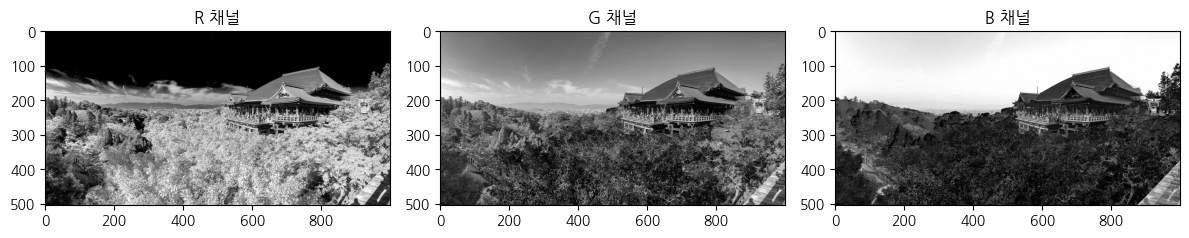

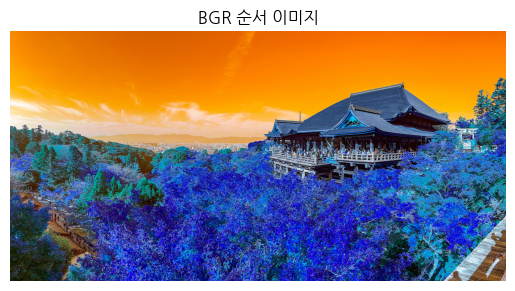

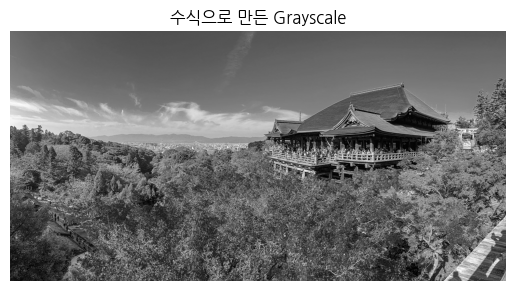

In [11]:
# R, G, B 채널 분리
R = img_arr[:, :, 0]
G = img_arr[:, :, 1]
B = img_arr[:, :, 2]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(R, cmap='gray'); plt.title("R 채널")
plt.subplot(1,3,2); plt.imshow(G, cmap='gray'); plt.title("G 채널")
plt.subplot(1,3,3); plt.imshow(B, cmap='gray'); plt.title("B 채널")
plt.tight_layout()
plt.show()

# 채널 순서를 BGR로 바꿔보기
bgr_arr = np.dstack([B, G, R])
plt.imshow(bgr_arr)
plt.axis('off')
plt.title("BGR 순서 이미지")
plt.show()

# 직접 그레이스케일 만들기
gray_arr = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)
plt.imshow(gray_arr, cmap='gray')
plt.axis('off')
plt.title("수식으로 만든 Grayscale")
plt.show()

**연습문제 2**
1. G(초록) 채널만 남기고 R,B는 0으로 한 이미지를 만들어서 시각화하세요. (힌트: `np.zeros_like` 로 R,B 대체)
2. R 채널만 극단적으로 강조한 이미지(R만 ×2, clip 255)를 만들어보세요.


## 3. 브로드캐스팅으로 밝기/대비 조절

핵심 NumPy 개념:
- 스칼라를 배열 전체에 더하거나 빼기 → 브로드캐스팅
- `np.clip`으로 값 범위(0~255) 제한


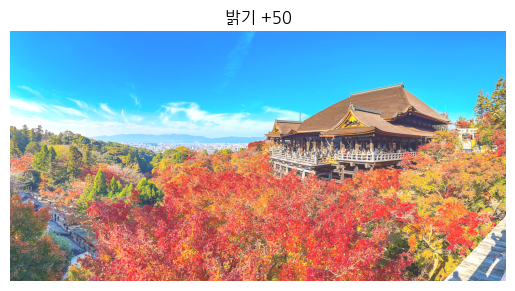

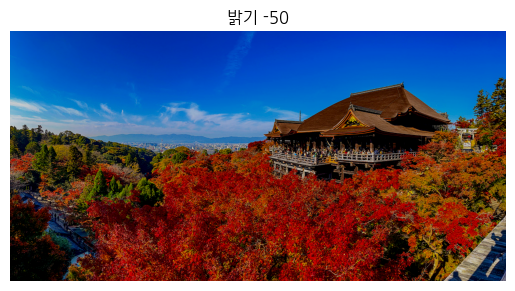

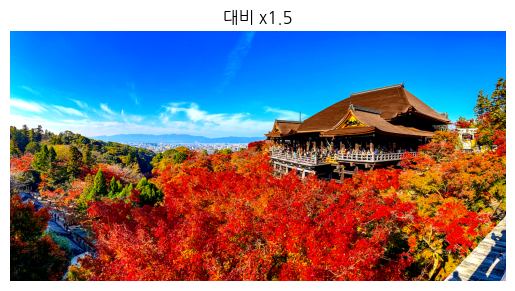

In [12]:
# 밝게 만들기 (+50)
brighter = img_arr.astype(np.int16) + 50
brighter = np.clip(brighter, 0, 255).astype(np.uint8)
plt.imshow(brighter)
plt.axis('off')
plt.title("밝기 +50")
plt.show()

# 어둡게 만들기 (-50)
darker = img_arr.astype(np.int16) - 50
darker = np.clip(darker, 0, 255).astype(np.uint8)
plt.imshow(darker)
plt.axis('off')
plt.title("밝기 -50")
plt.show()

# 대비(contrast) 조절
alpha = 1.5  # 1보다 크면 대비 ↑
contrast = (img_arr.astype(np.float32) - 128) * alpha + 128
contrast = np.clip(contrast, 0, 255).astype(np.uint8)
plt.imshow(contrast)
plt.axis('off')
plt.title("대비 x1.5")
plt.show()

**연습문제 3**
1. `alpha = 0.5`로 대비를 줄인 이미지를 만들어보고 원본과 비교해보세요.
2. 빨간 채널만 더 밝게(R채널 +80, clip 255) 하고 나머지 채널은 그대로 둔 이미지를 만들어보세요.


## 4. 자르기 / 붙이기 / 확대

핵심 NumPy 개념:
- 슬라이싱으로 crop
- `np.concatenate`로 붙이기
- `np.repeat`으로 단순 확대 (최근접 보간 비슷한 효과)


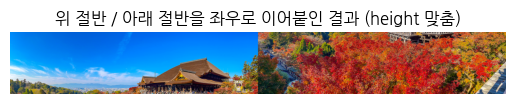

In [14]:
H, W, C = img_arr.shape
half_h = H // 2

top_half = img_arr[:half_h, :, :]
bottom_half = img_arr[half_h:, :, :]

# 두 덩어리 중 더 작은 높이를 기준으로 맞춘다
min_h = min(top_half.shape[0], bottom_half.shape[0])
top_half_aligned = top_half[:min_h, :, :]
bottom_half_aligned = bottom_half[:min_h, :, :]

horizontal_concat = np.concatenate([top_half_aligned, bottom_half_aligned], axis=1)

plt.imshow(horizontal_concat)
plt.axis('off')
plt.title("위 절반 / 아래 절반을 좌우로 이어붙인 결과 (height 맞춤)")
plt.show()


**연습문제 4**
1. 이미지의 가운데 100x100 크롭을 뽑은 뒤, `np.repeat`으로 4배 확대해서 보여보세요.
2. 왼쪽 절반과 오른쪽 절반을 반전/재배치해서 대칭 괴상한 콜라주 이미지를 만들어보세요.


## 5. 마스킹과 조건 처리 (Boolean indexing)

핵심 NumPy 개념:
- 특정 조건을 만족하는 픽셀만 선택하기 (`mask = (gray > 180)`)
- 마스크를 이용해 해당 영역 색만 바꾸기


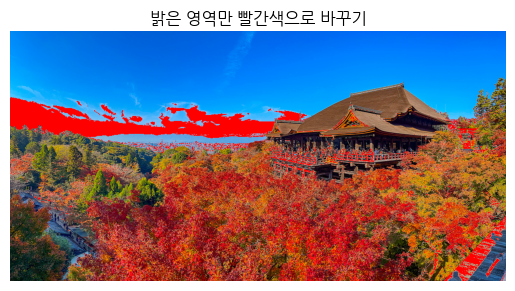

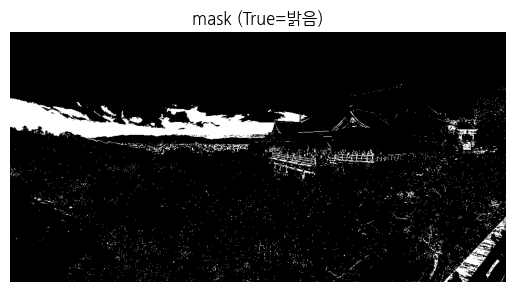

In [15]:
img_float = img_arr.astype(np.float32)
R = img_float[:, :, 0]
G = img_float[:, :, 1]
B = img_float[:, :, 2]

gray = 0.299*R + 0.587*G + 0.114*B
mask = gray > 180  # 밝은 영역만 True

highlight = img_arr.copy()
highlight[mask] = [255, 0, 0]  # 밝은 영역만 빨간색으로 칠하기

plt.imshow(highlight)
plt.axis('off')
plt.title("밝은 영역만 빨간색으로 바꾸기")
plt.show()

# 마스크 자체 시각화
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.title("mask (True=밝음)")
plt.show()

**연습문제 5**
1. 어두운 영역(`gray < 50`)만 파란색 `[0,0,255]` 으로 칠하는 이미지를 만들어보세요.
2. 초록끼가 강한 픽셀 (`G > 150`, `R < 100`, `B < 100`)만 노란색 `[255,255,0]` 으로 바꾸는 이미지를 만들어보세요.
3. 마스크로 선택된 픽셀 비율 = `(mask.sum() / mask.size) * 100` (%) 를 계산해보세요.


## 6. 필터(컨볼루션) 직접 만들기: 3x3 블러

아이디어: 각 픽셀을 주변 3x3 평균으로 바꾼다.
이건 "블러" 효과처럼 보인다.

이 예시는 직관적인 이중 for문 버전입니다. (느릴 수 있지만 이해용)


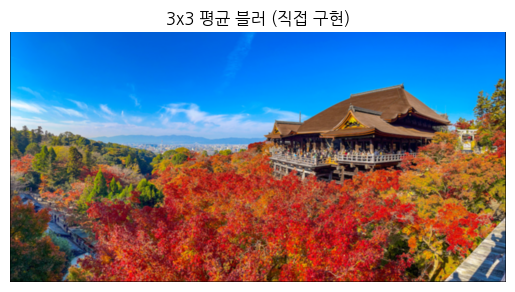

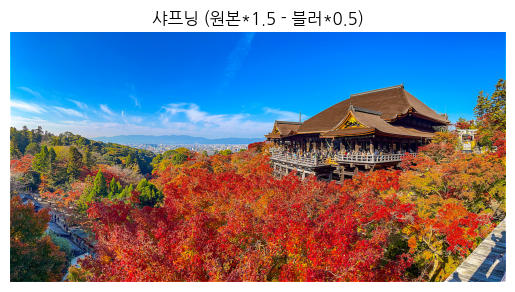

In [16]:
def blur3x3_naive(img_arr):
    # img_arr: (H,W,3) uint8
    img_f = img_arr.astype(np.float32)
    H, W, C = img_f.shape
    out = np.zeros_like(img_f)

    for y in range(1, H-1):
        for x in range(1, W-1):
            patch = img_f[y-1:y+2, x-1:x+2, :]   # (3,3,3)
            out[y, x, :] = patch.mean(axis=(0,1))
    return np.clip(out, 0, 255).astype(np.uint8)

blurred = blur3x3_naive(img_arr)

plt.imshow(blurred)
plt.axis('off')
plt.title("3x3 평균 블러 (직접 구현)")
plt.show()

# 샤프닝 아이디어: 원본*1.5 - 블러*0.5
sharp = (img_arr.astype(np.float32) * 1.5) - (blurred.astype(np.float32) * 0.5)
sharp = np.clip(sharp, 0, 255).astype(np.uint8)
plt.imshow(sharp)
plt.axis('off')
plt.title("샤프닝 (원본*1.5 - 블러*0.5)")
plt.show()

**연습문제 6**
1. 평균 대신 `patch.max(axis=(0,1))` (최댓값) 을 쓰면 어떤 이미지 느낌이 나나요?
2. 샤프닝 계수를 바꿔서 더 날카롭게 / 더 부드럽게 만드는 실험을 해보세요.


## 7. 여러 장의 이미지를 한 번에 다루기 (배치)

핵심 NumPy 개념:
- `np.stack` 으로 `(N,H,W,C)` 만들기
- axis=0 이 "몇 번째 이미지인지"를 나타내는 차원 역할을 한다


배치 shape: (2, 505, 1000, 3)
각 이미지 평균 밝기: [0.4043222  0.35553625]


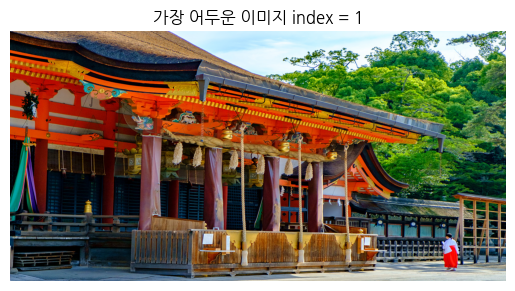

In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 두 이미지 불러오기
img_a = Image.open("./data/sample1.jpg")
img_b = Image.open("./data/sample2.jpg")

# ① 기준 크기 정하기 (예: 첫 번째 이미지 크기)
target_size = img_a.size  # (W, H)

# ② 두 번째 이미지를 리사이즈해서 맞춤
img_b_resized = img_b.resize(target_size)

# ③ NumPy 배열로 변환
arr_a = np.array(img_a)
arr_b = np.array(img_b_resized)

# ④ 스택 만들기
batch = np.stack([arr_a, arr_b], axis=0)
print("배치 shape:", batch.shape)

# ⑤ 평균 밝기 계산
batch_float = batch.astype(np.float32) / 255.0
R = batch_float[..., 0]
G = batch_float[..., 1]
B = batch_float[..., 2]
batch_gray = 0.299*R + 0.587*G + 0.114*B
avg_brightness = batch_gray.mean(axis=(1,2))
print("각 이미지 평균 밝기:", avg_brightness)

# ⑥ 가장 어두운 이미지 표시
darkest_idx = np.argmin(avg_brightness)
plt.imshow(batch[darkest_idx])
plt.axis('off')
plt.title(f"가장 어두운 이미지 index = {darkest_idx}")
plt.show()


**연습문제 7**
1. 네 장의 이미지를 불러와 `(4,H,W,C)` 형태의 `batch4`를 만들고,
   각 이미지의 (평균 R, 평균 G, 평균 B) 값을 표처럼 출력해보세요.
2. 가장 밝은 이미지를 골라서 시각화해보세요.


## 8. 미니 프로젝트: 돋보기 스티커 합성

**목표**
1. 원본 이미지에서 가운데 100x100 영역을 뽑는다.
2. 그 영역을 `np.repeat`으로 4배 확대한다 (돋보기 효과).
3. 그 확대 이미지를 원본 오른쪽 아래에 합성한다.
4. 최종 이미지를 저장한다.


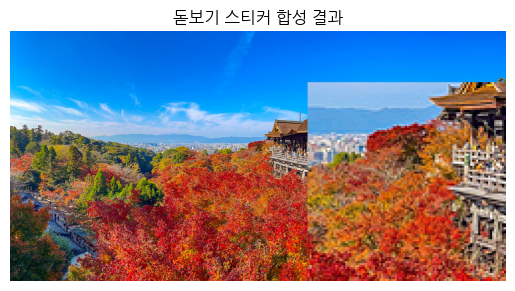

result_preview.png 저장 완료


In [21]:
from PIL import Image

img = np.array(Image.open("./data/sample1.jpg"))
H, W, C = img.shape

# 1) 가운데 100x100 crop
cy, cx = H//2, W//2
crop = img[cy-50:cy+50, cx-50:cx+50, :]  # (100,100,3)

# 2) 4배 확대 (최근접 샘플링 흉내)
zoom = np.repeat(np.repeat(crop, 4, axis=0), 4, axis=1)  # (400,400,3)

# 3) 원본 오른쪽 아래에 붙이기
out = img.copy()

zoom_h, zoom_w, _ = zoom.shape
paste_y = H - zoom_h
paste_x = W - zoom_w

# 만약 zoom이 너무 커서 이미지 밖으로 나가면 잘라서 붙이기
zoom_h2 = min(zoom_h, H)
zoom_w2 = min(zoom_w, W)
out[H-zoom_h2:H, W-zoom_w2:W, :] = zoom[zoom_h-zoom_h2:zoom_h, zoom_w-zoom_w2:zoom_w, :]

plt.imshow(out)
plt.axis('off')
plt.title("돋보기 스티커 합성 결과")
plt.show()

# 4) 저장
Image.fromarray(out).save("./data/result_preview.png")
print("result_preview.png 저장 완료")

**추가 미션 (도전)**
- 스티커(zoom)에 빨간 테두리를 추가해보세요. (힌트: `zoom_border = zoom.copy()` 후, 가장자리에 `[255,0,0]` 대입)
- 스티커 붙이기 전에 대비/밝기를 조정해서 더 눈에 띄게 만들어보세요.
- 오른쪽 아래 대신 왼쪽 위나 중앙에 붙여보세요.

---
### 끝!
이 노트북을 따라가면 NumPy의 핵심 개념(슬라이싱, 브로드캐스팅, 마스킹, 축, 스택 등)을 모두 '이미지'라는 직관적인 데이터로 연습할 수 있습니다.
